
<center>

# Time-Series Forecasting in Financial Markets

##  Course Details

##### **Programme:** Master of Science in Artificial Intelligence
##### **Course:** CSA 821 Machine Learning
##### **Module:** Module 8 Recurrent Neural Networks (Rnns) and Lstms
##### **Name:** Marrion Kiprop Cherop
##### **Reg Number:** ST62/80971/2024
</center>

## 1. Introduction

To predict the next day’s closing price for a stock using the previous 30 days of closing prices, we can't use normal feed forward deep learning model. Here we need a model that has memory and can remember previous trends. 

### 1.1 Data Set

Here, we use a synthetic data to simulate real world trading. This is chosen because if we use fully random data, there is no pattern to learn. So instead, we create synthetic stock-like data with:

a) a trend  
b) some seasonality  
c) some noise  

This gives the LSTM something meaningful to learn.

## 2. LSTM implementation using Synthetic Data

I0000 00:00:1776034518.122725   10553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776034518.123193   10553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776034518.167717   10553 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776034519.721147   10553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

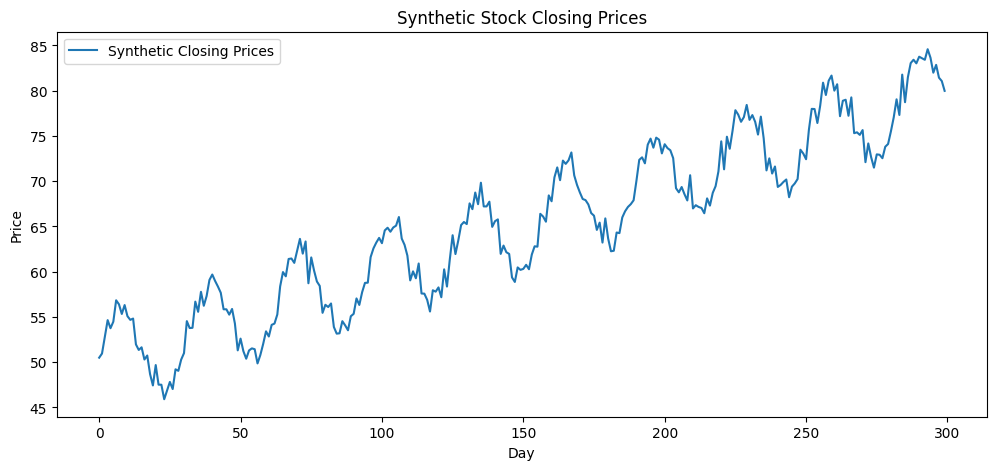

X shape: (270, 30, 1)
y shape: (270, 1)
Training samples: 216
Testing samples: 54


E0000 00:00:1776034520.184220   10553 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/langstkip/workspace/langstEnv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0642 - val_loss: 0.0106
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113 - val_loss: 0.0234
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0076 - val_loss: 0.0101
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0068 - val_loss: 0.0115
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065 - val_loss: 0.0101
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0061 - val_loss: 0.0103
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0058 - val_loss: 0.0106
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0054 - val_loss: 0.0070
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - val_loss: 0.0085
Epoch 10/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0046 - val_loss: 0.0054
Epoch 11/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0066
Epoch 12/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - 

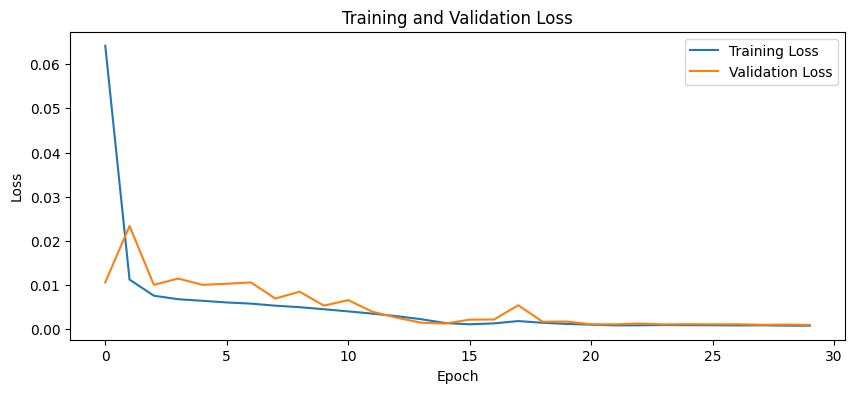

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
MSE: 1.5100
MAE: 0.9306


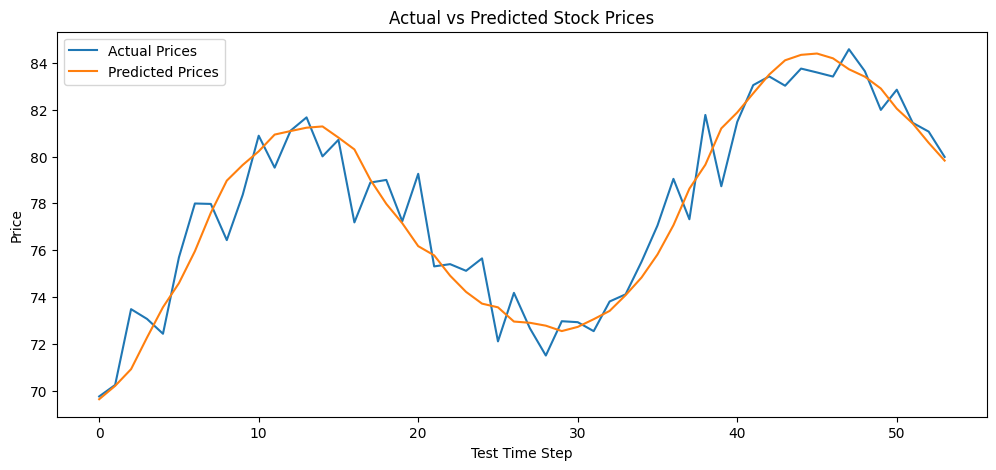

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------
# 1. Generate synthetic stock data
# -----------------------------
np.random.seed(42)

days = 300
time = np.arange(days)

# Synthetic stock-like signal:
# trend + seasonal movement + random noise
prices = 50 + 0.1 * time + 5 * np.sin(0.2 * time) + np.random.normal(0, 1, days)

# Plot the synthetic prices
plt.figure(figsize=(12, 5))
plt.plot(prices, label="Synthetic Closing Prices")
plt.title("Synthetic Stock Closing Prices")
plt.xlabel("Day")
plt.ylabel("Price")
plt.legend()
plt.show()

# -----------------------------
# 2. Normalize the data
# -----------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices.reshape(-1, 1))

# -----------------------------
# 3. Create sequences of 30 days
# -----------------------------
def create_dataset(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_dataset(prices_scaled, window_size)

# Reshape for LSTM: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

# -----------------------------
# 4. Train-test split
# -----------------------------
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# -----------------------------
# 5. Build LSTM model
# -----------------------------
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# -----------------------------
# 6. Train the model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# -----------------------------
# 7. Plot training history
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -----------------------------
# 8. Make predictions
# -----------------------------
y_pred = model.predict(X_test)

# Inverse transform to original scale
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# -----------------------------
# 9. Evaluate the model
# -----------------------------
mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

# -----------------------------
# 10. Plot actual vs predicted
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label="Actual Prices")
plt.plot(y_pred_inv, label="Predicted Prices")
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Test Time Step")
plt.ylabel("Price")
plt.legend()
plt.show()

## 3. Data Preparation and Model Design

To demonstrate time-series forecasting with LSTM, synthetic stock price data was generated rather than using real market data. The synthetic series was designed to mimic basic stock-like behavior by combining four components: a base price level, a small upward trend, a cyclical fluctuation, and random noise. In general form, the synthetic price at time $t$ can be expressed as

$$
P_t = \alpha + \beta t + \gamma \sin(\omega t) + \epsilon_t
$$

where:

- $\alpha$ represents the base price,
- $\beta t$ represents a linear upward trend over time,
- $\gamma \sin(\omega t)$ introduces periodic fluctuation,
- $\epsilon_t$ represents random noise.

This formulation ensures that the generated data contains an underlying temporal structure, unlike purely random values, and therefore provides a meaningful pattern for the LSTM model to learn.

Before training the model, the price values were scaled to the interval $[0,1]$ using Min-Max normalization. This transformation is given by

$$
P_t^{(\text{scaled})} = \frac{P_t - P_{\min}}{P_{\max} - P_{\min}}
$$

where $P_{\min}$ and $P_{\max}$ are the minimum and maximum prices in the dataset respectively. Scaling is important because LSTM networks generally train more effectively when the numerical range of the inputs is controlled, leading to more stable optimization and faster convergence.

A sliding-window approach was then used to convert the time series into supervised learning samples. For each training example, the input consisted of the previous 30 days of closing prices, while the target was the closing price on the following day. Thus, if the sequence of prices is denoted by

$$
\{P_1, P_2, P_3, \dots, P_T\},
$$

then one training pair is constructed as

$$
X^{(1)} = [P_1, P_2, \dots, P_{30}], \qquad y^{(1)} = P_{31}.
$$

The next sample becomes

$$
X^{(2)} = [P_2, P_3, \dots, P_{31}], \qquad y^{(2)} = P_{32},
$$

and this process continues throughout the dataset. In this way, the model learns to map a fixed-length historical window to the next time-step value.

Because LSTM models require three-dimensional input, the resulting dataset was reshaped into the form

$$
(\text{samples}, \text{timesteps}, \text{features}).
$$

In this project:

- the number of **timesteps** was 30, since each input contains 30 days of history,
- the number of **features** was 1, because only the closing price was used.

Accordingly, each input sample had the structure

$$
X \in \mathbb{R}^{30 \times 1},
$$

and the full dataset was represented as a collection of such samples.

For model design, a simple univariate LSTM forecasting architecture was used. The network consisted of a single LSTM layer with 50 hidden units, followed by a dense output layer with one neuron. The LSTM layer was responsible for learning temporal dependencies and memory patterns in the 30-day input sequence, while the dense layer transformed the learned representation into a single numerical prediction corresponding to the next day’s closing price.

Model performance was evaluated using two standard regression metrics: Mean Squared Error (MSE) and Mean Absolute Error (MAE). The Mean Squared Error is defined as

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where $y_i$ is the true value and $\hat{y}_i$ is the predicted value. This metric penalizes larger errors more strongly because the errors are squared. The Mean Absolute Error is defined as

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

and measures the average magnitude of prediction error in absolute terms. Together, these two metrics provide a useful picture of forecasting performance, with MSE emphasizing large deviations and MAE giving a more directly interpretable average error.

## 4. Results and Evaluation

The model showed strong learning behavior over the 30 training epochs. The training loss declined substantially from 0.0642 in the first epoch to 0.0008186 by the final epoch, while the validation loss also improved from 0.0106 to 0.0010. This consistent reduction in both loss curves suggests that the LSTM was able to learn the temporal structure embedded in the synthetic stock series. The closeness of the final training and validation losses also indicates that the model generalized reasonably well to unseen data, with no strong evidence of severe overfitting.

When evaluated on the test set, the model achieved a Mean Squared Error (MSE) of 1.5100 and a Mean Absolute Error (MAE) of 0.9306. These values indicate that the predicted next-day prices were, on average, fairly close to the actual values. The MAE of less than 1 suggests that the model’s typical prediction error was under one price unit, while the MSE confirms that large deviations were relatively limited. 

The results show that the LSTM was effective at capturing the trend and cyclical behavior of the synthetic time series, though such performance should be interpreted as a demonstration of sequence learning rather than a reflection of real-world financial forecasting difficulty.